In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]  # or any installed font



=== Φ* Stability & Maturity Summary ===

  Model  Mean Φ*   Std Φ*    CV Φ*  Final Φ* Slope  Rolling Var Φ*
0   RNN  8.50565  4.21817  0.49593        -0.02424         3.53455
1   GRU  2.39234  1.34677  0.56295        -0.00764         0.28038
2  LSTM  8.88134  4.22176  0.47535         0.03353         5.65545


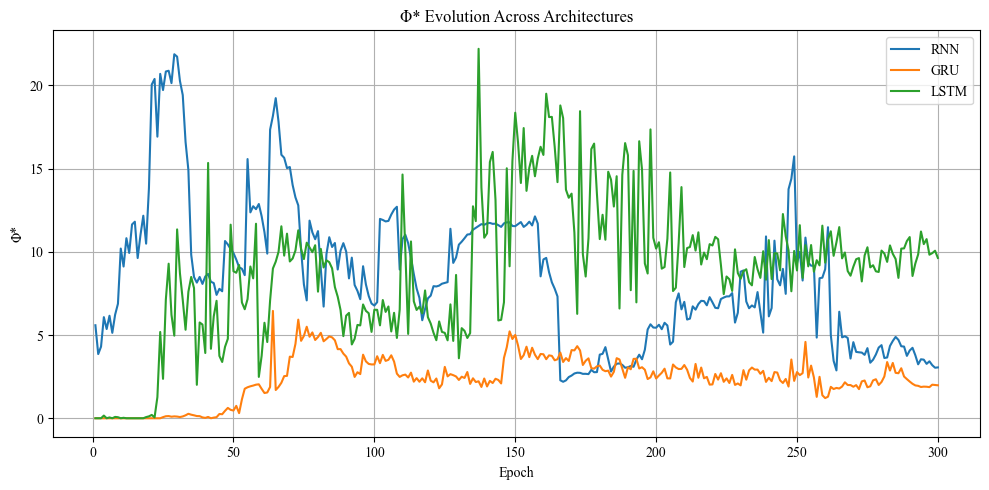

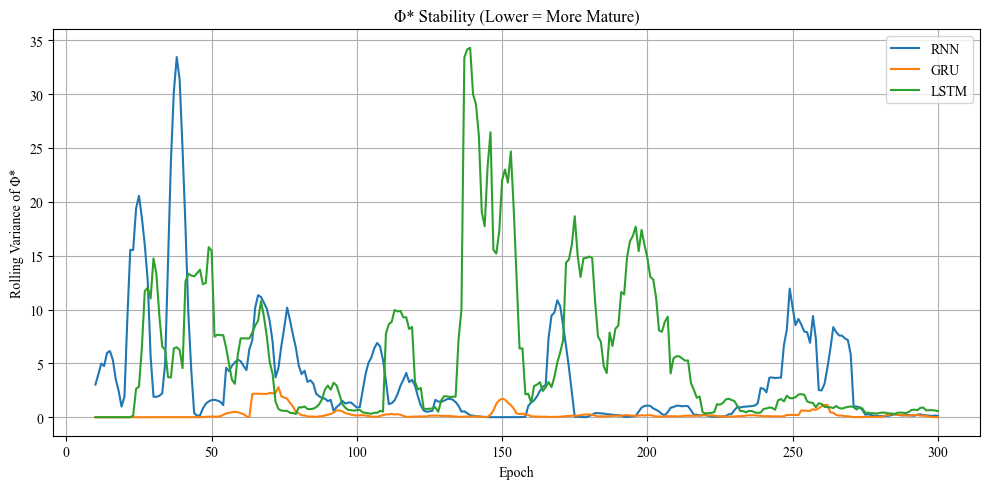

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -------------------------------
# CONFIG
# -------------------------------
CSV_PATHS = {
    "RNN": "./CSV Files/rnn_training_summary.csv",
    "GRU": "./CSV Files/gru_training_summary.csv",
    "LSTM": "./CSV Files/lstm_training_summary.csv"
}

ROLLING_WINDOW = 10   # epochs
TAIL_EPOCHS = 30      # maturity window

# -------------------------------
# LOAD DATA
# -------------------------------
data = {}
for model, path in CSV_PATHS.items():
    df = pd.read_csv(path)
    assert "phi" in df.columns, f"{model} CSV must contain 'phi_star'"
    data[model] = df

# -------------------------------
# STABILITY & MATURITY METRICS
# -------------------------------
metrics = []

for model, df in data.items():
    phi = df["phi"].values
    epochs = df["epoch"].values

    # Global statistics
    mean_phi = np.mean(phi)
    std_phi = np.std(phi)
    cv_phi = std_phi / mean_phi

    # Maturity: slope of last N epochs
    tail_phi = phi[-TAIL_EPOCHS:]
    tail_epochs = epochs[-TAIL_EPOCHS:]
    slope, _, _, _, _ = linregress(tail_epochs, tail_phi)

    # Rolling variance
    rolling_var = pd.Series(phi).rolling(ROLLING_WINDOW).var().mean()

    metrics.append({
        "Model": model,
        "Mean Φ*": mean_phi,
        "Std Φ*": std_phi,
        "CV Φ*": cv_phi,
        "Final Φ* Slope": slope,
        "Rolling Var Φ*": rolling_var
    })

metrics_df = pd.DataFrame(metrics)
print("\n=== Φ* Stability & Maturity Summary ===\n")
print(metrics_df.round(5))

# -------------------------------
# VISUALIZATION
# -------------------------------
plt.figure(figsize=(10, 5))
for model, df in data.items():
    plt.plot(df["epoch"], df["phi"], label=model)

plt.xlabel("Epoch")
plt.ylabel("Φ*")
plt.title("Φ* Evolution Across Architectures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# ROLLING VARIANCE PLOT
# -------------------------------
plt.figure(figsize=(10, 5))
for model, df in data.items():
    rolling_var = (
        df["phi"]
        .rolling(ROLLING_WINDOW)
        .var()
    )
    plt.plot(df["epoch"], rolling_var, label=model)

plt.xlabel("Epoch")
plt.ylabel("Rolling Variance of Φ*")
plt.title("Φ* Stability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


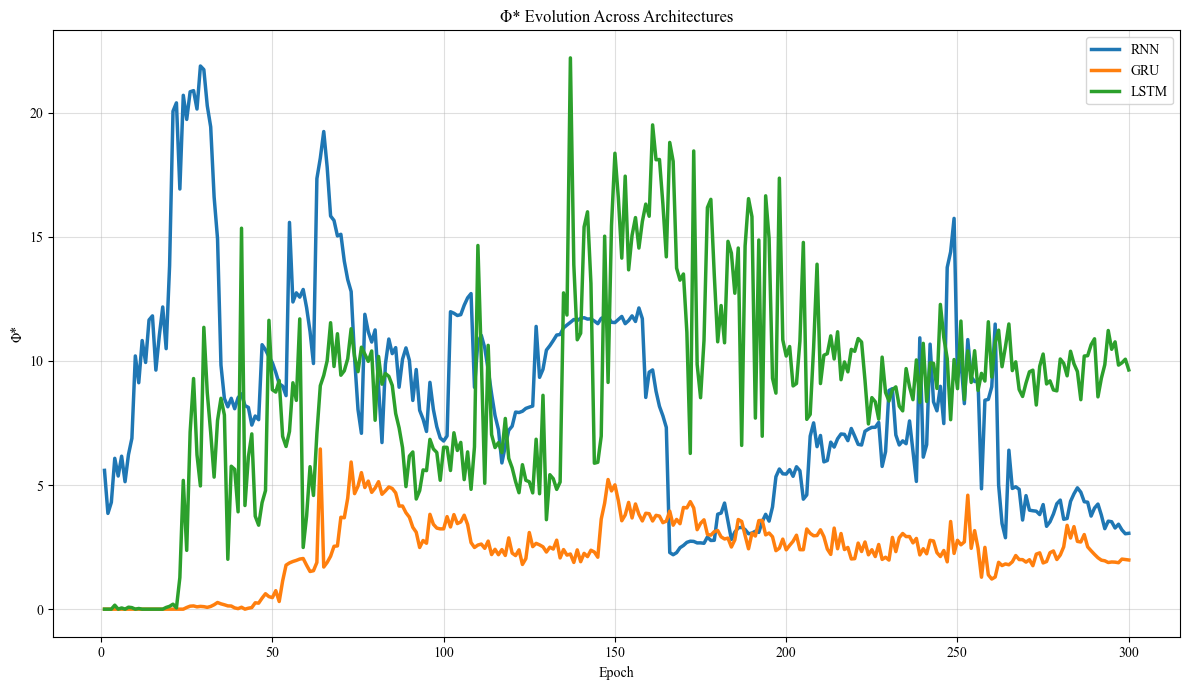

In [9]:
import os
SAVE_DIR = "./PNG Files(TimesNewRoman)"
os.makedirs(SAVE_DIR, exist_ok=True)

plt.figure(figsize=(12, 7))
for model, df in data.items():
    plt.plot(df["epoch"], df["phi"], label=model, linewidth=2.5)

plt.xlabel("Epoch")
plt.ylabel("Φ*")
plt.title("Φ* Evolution Across Architectures")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Φ* Evolution Across Architectures.png", dpi=300)
plt.show()
